<a href="https://colab.research.google.com/github/roboy88/Financial-Suitability-and-Risk-Modeling-IUL-Insurance-Investment-and-Behave-Segmentation-with-Python/blob/main/Copy_of_Financial_Suitability_and_Risk_Modeling_IUL%2C_Insurance%2C_Investment%2C_and_Behavioral_Segmentation_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving insurance_claims.csv to insurance_claims.csv
Saving Stocks_Data_10yrs.xlsx to Stocks_Data_10yrs.xlsx
Saving Data_final.csv to Data_final.csv
Saving bank_transactions_data_2.csv to bank_transactions_data_2.csv
✅ Files loaded:
Insurance: (1338, 7)
Bank Transactions: (2512, 16)
Data Final: (105, 11)
Stocks: (10064, 7)
Insurance Accuracy: 0.9402985074626866
Classification Report:
               precision    recall  f1-score   support

        High       0.96      0.91      0.93       122
         Low       0.93      0.97      0.95       146

    accuracy                           0.94       268
   macro avg       0.94      0.94      0.94       268
weighted avg       0.94      0.94      0.94       268



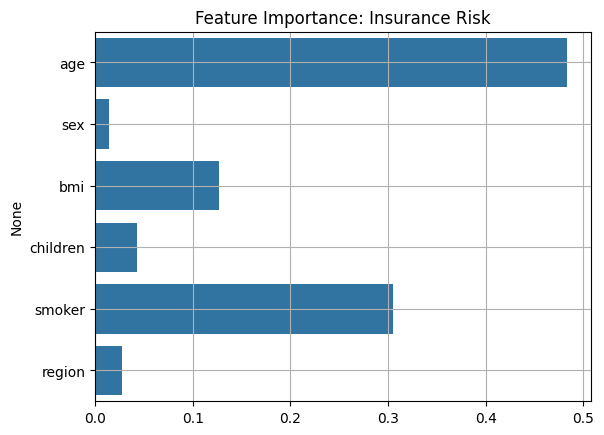


Banking Clusters:
 cluster
2    270
1    142
0     83
Name: count, dtype: int64


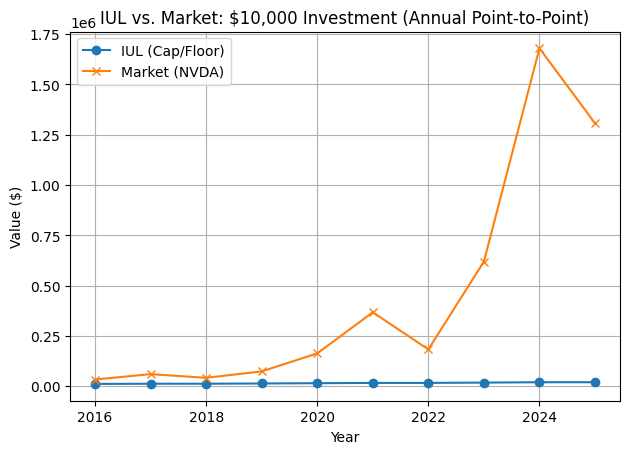

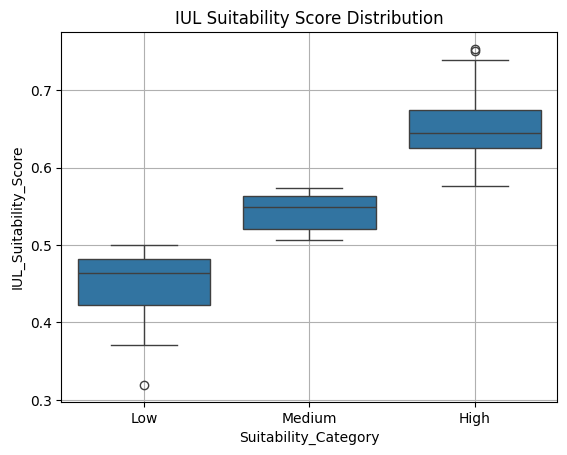


Suitability Category Counts:
 Suitability_Category
Low       37
High      35
Medium    33
Name: count, dtype: int64

Top High-Suitability Profiles:
     O_score   C_score   E_score   A_score   N_score  Numerical Aptitude  \
0  0.410029  0.867572  0.086822  0.345336  0.256214            0.966463   
2  0.508850  0.546689  1.000000  0.708674  0.405354            0.509146   
3  0.951327  0.886248  0.207752  0.399345  0.319312            0.762195   
5  0.852507  0.585739  0.379845  0.363339  0.319312            0.542683   
7  0.901180  0.735144  0.431008  0.454992  0.340344            0.847561   

   Spatial Aptitude  Perceptual Aptitude  Abstract Reasoning  \
0          0.322206             0.595577            0.770932   
2          0.274311             0.543444            0.578199   
3          0.435414             0.543444            1.000000   
5          0.984035             0.736177            0.928910   
7          0.274311             0.368088            0.982622   

   Verbal Reas

In [ ]:
# === SETUP: LIBRARIES ===
# === SETUP: LIBRARIES ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# === STEP 1: UPLOAD FILES ===
from google.colab import files
uploaded = files.upload()  # Select all required files manually when prompted

# === STEP 2: LOAD DATASETS FROM UPLOAD ===
insurance = pd.read_csv("insurance_claims.csv")
bank = pd.read_csv("bank_transactions_data_2.csv")
data_final = pd.read_csv("Data_final.csv")
stocks = pd.read_excel("Stocks_Data_10yrs.xlsx")

# === STEP 3: Confirm Files Are Loaded ===
print("✅ Files loaded:")
print("Insurance:", insurance.shape)
print("Bank Transactions:", bank.shape)
print("Data Final:", data_final.shape)
print("Stocks:", stocks.shape)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# === LOAD DATASETS (UPLOAD MANUALLY INTO COLAB FIRST) ===
insurance = pd.read_csv("insurance_claims.csv")
bank = pd.read_csv("bank_transactions_data_2.csv")
data_final = pd.read_csv("Data_final.csv")
stocks = pd.read_excel("Stocks_Data_10yrs.xlsx")

# === PART 1: INSURANCE FRAUD / RISK MODEL ===
insurance_encoded = insurance.copy()
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    insurance_encoded[col] = le.fit_transform(insurance_encoded[col])
X = insurance_encoded.drop('charges', axis=1)
y = pd.qcut(insurance_encoded['charges'], q=2, labels=["Low", "High"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print("Insurance Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
sns.barplot(x=rf_model.feature_importances_, y=X.columns)
plt.title("Feature Importance: Insurance Risk")
plt.grid(True)
plt.show()

# === PART 2: BANKING BEHAVIOR SEGMENTATION ===
bank['TransactionDate'] = pd.to_datetime(bank['TransactionDate'])
bank_summary = bank.groupby('AccountID').agg({
    'TransactionAmount': 'mean',
    'TransactionID': 'count',
    'AccountBalance': 'max',
    'Channel': pd.Series.nunique,
    'TransactionDuration': 'mean',
    'LoginAttempts': 'max',
    'CustomerAge': 'max',
    'CustomerOccupation': 'last'
}).reset_index()

bank_summary.columns = [
    'AccountID', 'avg_transaction_amount', 'num_transactions', 'max_balance',
    'unique_channels', 'avg_duration', 'max_login_attempts', 'age', 'occupation'
]

bank_summary['occupation_encoded'] = LabelEncoder().fit_transform(bank_summary['occupation'])

features = ['avg_transaction_amount', 'num_transactions', 'max_balance',
            'unique_channels', 'avg_duration', 'max_login_attempts', 'age', 'occupation_encoded']
X_cluster = StandardScaler().fit_transform(bank_summary[features])
kmeans = KMeans(n_clusters=3, random_state=42)
bank_summary['cluster'] = kmeans.fit_predict(X_cluster)

print("\nBanking Clusters:\n", bank_summary['cluster'].value_counts())

# === PART 3: IUL CREDITING VS. MARKET (S&P/NVDA) ===
stocks['Date'] = pd.to_datetime(stocks['Date'])
stocks = stocks.sort_values('Date')
nvda = stocks[stocks['Ticker'] == 'NVDA'][['Date', 'Close']].dropna()
nvda['Year'] = nvda['Date'].dt.year
annual_returns = nvda.groupby('Year')['Close'].last().pct_change().dropna()
iul_returns = annual_returns.clip(lower=0, upper=0.10)

initial = 10000
iul_growth, market_growth = [initial], [initial]

for iul_r, mkt_r in zip(iul_returns, annual_returns):
    iul_growth.append(iul_growth[-1] * (1 + iul_r))
    market_growth.append(market_growth[-1] * (1 + mkt_r))

iul_growth, market_growth = iul_growth[1:], market_growth[1:]

growth_df = pd.DataFrame({
    'Year': annual_returns.index,
    'IUL_Value': iul_growth,
    'Market_Value': market_growth,
    'IUL_Returns': iul_returns.values,
    'Market_Returns': annual_returns.values
})

plt.plot(growth_df['Year'], growth_df['IUL_Value'], label='IUL (Cap/Floor)', marker='o')
plt.plot(growth_df['Year'], growth_df['Market_Value'], label='Market (NVDA)', marker='x')
plt.title("IUL vs. Market: $10,000 Investment (Annual Point-to-Point)")
plt.xlabel("Year")
plt.ylabel("Value ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === PART 4: IUL SUITABILITY SCORING (BASED ON PSYCHOMETRICS) ===
df = data_final.copy()
features_to_use = ['O_score', 'C_score', 'E_score', 'A_score', 'N_score',
                   'Numerical Aptitude', 'Spatial Aptitude', 'Perceptual Aptitude',
                   'Abstract Reasoning', 'Verbal Reasoning']

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features_to_use]), columns=features_to_use)

df_scaled['IUL_Suitability_Score'] = (
    0.15 * df_scaled['O_score'] +
    0.20 * df_scaled['C_score'] +
    0.10 * (1 - df_scaled['N_score']) +
    0.20 * df_scaled['Numerical Aptitude'] +
    0.15 * df_scaled['Abstract Reasoning'] +
    0.10 * df_scaled['A_score'] +
    0.10 * df_scaled['E_score']
)

df_scaled['Suitability_Category'] = pd.qcut(df_scaled['IUL_Suitability_Score'], 3, labels=['Low', 'Medium', 'High'])
df_scaled['Career'] = df['Career']

# Visualize
sns.boxplot(x='Suitability_Category', y='IUL_Suitability_Score', data=df_scaled)
plt.title("IUL Suitability Score Distribution")
plt.grid(True)
plt.show()

print("\nSuitability Category Counts:\n", df_scaled['Suitability_Category'].value_counts())
print("\nTop High-Suitability Profiles:\n", df_scaled[df_scaled['Suitability_Category'] == 'High'].head())
